In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%run "./usefulfunctions.ipynb"
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

In [2]:
target_resolution = 1080 #Height in pixels (in range (0,2100))
img_original = cv2.imread("media//peas_1.bmp")
img_crop = img_original.copy()[:-63,14:] # To preserve aspect ratio (16/9)
cv2.namedWindow('Image',cv2.WINDOW_NORMAL)
cv2.setWindowProperty('Image', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
scale = target_resolution/img_crop.shape[0]
img = cv2.resize(img_crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
cv2.imshow("Image",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [89]:
y = len(img)
x = len(img[0])
img_bnw = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_median  = cv2.medianBlur(img_bnw,7)

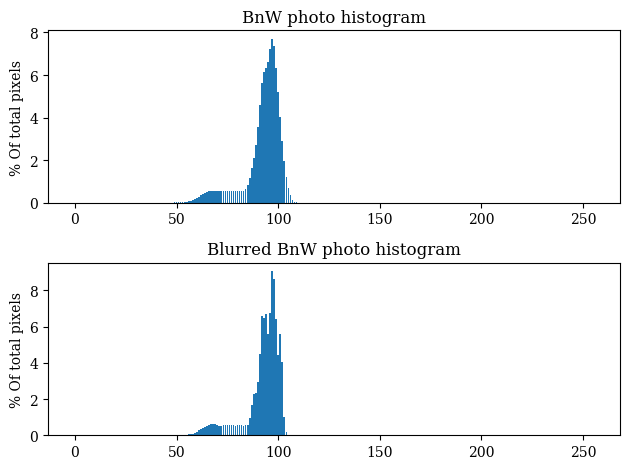

In [90]:
histogram_noblur = np.zeros(256)
histogram_blur = np.zeros(256)
for i in range(y):
    for j in range(x):
        histogram_noblur[img_bnw[i][j]]+=1
        histogram_blur[img_median[i][j]]+=1

histogram_noblur /= 0.01*x*y
histogram_blur /= 0.01*x*y

fig, [ax1,ax2] = plt.subplots(2,1)
ax1.bar(np.arange(256),histogram_noblur)
ax2.bar(np.arange(256),histogram_blur)
ax1.set_title("BnW photo histogram")
ax2.set_title("Blurred BnW photo histogram")
ax1.set_ylabel("% Of total pixels")
ax2.set_ylabel("% Of total pixels")
plt.tight_layout()
plt.show()

In [91]:
""" for i in range(75,100):
    print(i,histogram_blur[i]) """

' for i in range(75,100):\n    print(i,histogram_blur[i]) '

In [92]:
_,img_bin = cv2.threshold(img_median,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
cv2.imshow("Image",img_bnw)
cv2.waitKey(0)
cv2.imshow("Image",img_median)
cv2.waitKey(0)
cv2.imshow("Image",img_bin)
cv2.waitKey(0)
cv2.destroyAllWindows()

MORPHOLOGICAL TRANSFORMATIONS

In [113]:
kernelsize = 30
closed = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE,  np.ones((kernelsize,kernelsize), np.uint8))
kernelsize = 10
closed_detailed = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE,  np.ones((kernelsize,kernelsize), np.uint8))
cv2.imshow("Image",img_bin)
cv2.waitKey(0)
cv2.imshow("Image",closed)
cv2.waitKey(0)
cv2.imshow("Image",closed_detailed)
cv2.waitKey(0)
cv2.destroyAllWindows()

Filter out specks

In [116]:
contours, hierarchy = cv2.findContours(closed, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
fullyclosed = closed.copy()
for c,h in zip(contours, hierarchy[0]):
    if h[3] != -1:
        cv2.drawContours(fullyclosed,[c],-1,255,thickness=cv2.FILLED)

contours2, hierarchy2 = cv2.findContours(img_bin, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
fullyclosed2 = img_bin.copy()
for c,h in zip(contours, hierarchy[0]):
    if h[3] != -1:
        cv2.drawContours(fullyclosed2,[c],-1,255,thickness=cv2.FILLED)

cv2.imshow("Image",closed)
cv2.waitKey(0)
cv2.imshow("Image",fullyclosed)
cv2.waitKey(0)
cv2.imshow("Image",fullyclosed2)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [100]:
N,P = classify(fullyclosed)

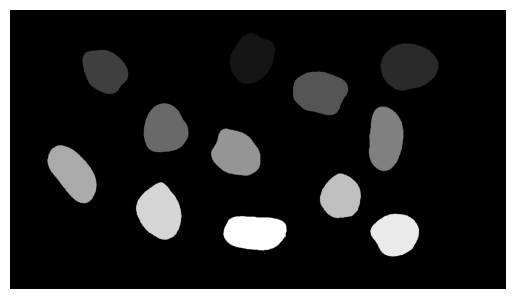

In [101]:
plt.figure()
plt.axis("off")
plt.imshow(P,cmap="gray",vmin=0,vmax=N)
plt.show()

Area calculations

In [102]:
bean_area = np.zeros(N,np.uint16) #AREA IN TOTAL PIXELS
bean_color = np.zeros(N) #AVERAGE GRAYSCALE COLOR / INTENSITY
bean_perimeter = np.zeros(N)
for i in range(len(P)):
    for j in range(len(P[0])):
        if P[i][j]==0:
            continue
        else:
            bean_area[int(P[i][j]-1)]+=1
            bean_color[int(P[i][j]-1)]+=img[i][j][0] #ANY CHANNEL WILL DO
for i in range(N):
    bean_color[i] = bean_color[i]/bean_area[i]

h,w = P.shape
avgcolor = np.zeros((h,w),np.uint8)

for i in range(len(P)):
    for j in range(len(P[0])):
        if P[i][j] in range(1,N+1):
            avgcolor[i][j]=bean_color[int(P[i][j]-1)]
            neighbors = [int(j) for j in checkNeighbors(i,j,P)]
            if 0. in neighbors:
                bean_perimeter[int(P[i][j]-1)]+=1

bean_circularity = [np.round(4*np.pi*bean_area[i]/bean_perimeter[i]**2,2) for i in range(N)]

In [104]:
contours,hierarchy = cv2.findContours(fullyclosed,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)
img_contour = img.copy()
cv2.drawContours(img_contour,contours,-1,tuple(np.random.randint(0,255,3).tolist()),2)
cv2.imshow("Image",img_contour)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [60]:
print(bean_perimeter)
print(bean_circularity)


[755. 805. 689. 761. 723. 761. 740. 823. 657. 791. 703. 751.]
[0.56, 0.61, 0.6, 0.6, 0.61, 0.58, 0.59, 0.5, 0.61, 0.56, 0.59, 0.59]


In [48]:
cv2.imshow("Image",avgcolor)
cv2.waitKey(0)
cv2.destroyAllWindows()